## Layer 1

In [0]:
from pyspark.sql import functions as F

bucket = "s3://my-de-case-study-datalake/"
assignment_bucket = "s3a://merkle-de-interview-case-study/de/"

In [0]:
item_df = spark.read.csv(
    "s3a://merkle-de-interview-case-study/de/item.csv",
    header=True,
    inferSchema=False,
    multiLine=False,
)

item_df.write.mode("overwrite").saveAsTable("raw_layer.item_raw")

In [0]:
# do the same for the 2nd file

event_df = spark.read.csv(
    "s3a://merkle-de-interview-case-study/de/event.csv",
    header=True,
    inferSchema=False,
    multiLine=False,
    quote='"',       # treat double quotes as enclosing quotes
    escape='"'
)

### Saving to my bronze layer

In [0]:
event_df.write.format("delta").mode("overwrite").save(f"{bucket}bronze/event_raw")

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7872652987629772>, line 1
----> 1 event_df.write \
      2     .format("delta") \
      3     .mode("overwrite") \
      4     .save(f"{bucket}bronze/event_raw")

NameError: name 'event_df' is not defined

In [0]:
item_df.write.format("delta").mode("overwrite").save(f"{bucket}bronze/item_raw")

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

Upon re-run we can skip the initial load and write steps

In [0]:
item_df = spark.read.format("delta").load(f"{bucket}bronze/item_raw")
event_df = spark.read.format("delta").load(f"{bucket}bronze/event_raw")

## Understanding the structure
The cells within this scope are used initially to visualize and understand any issues and limitations that may be considered while processing the data.
They are not parts of the pipeline, but they allow for the step "Using your business acumen understand the content of the files."

In [0]:
display(item_df.head(10))

adjective,category,created_at,id,modifier,name,price
fuzzy,contraption,2014-01-15 21:36:09,2512.0,carrying_case,fuzzy contraption carrying_case,150.0
null,instrument,2013-05-14 05:20:50,482.0,refill,instrument refill,35.2
industrial-strength,module,2014-02-04 19:28:32,2446.0,null,industrial-strength module,300.0
digital,tool,2013-02-25 12:23:18,1312.0,carrying_case,digital tool carrying_case,16.5
miniature,device,2013-08-05 17:20:45,3556.0,cleaner,miniature device cleaner,16.5
rechargable,contraption,2013-09-12 06:27:01,131.0,cleaner,rechargable contraption cleaner,195.0
null,instrument,2013-10-07 09:38:14,1178.0,how-to-manual,instrument how-to-manual,0.0
prize-winning,mechanism,2013-09-09 09:32:18,110.0,storage_unit,prize-winning mechanism storage_unit,41.25
null,mechanism,2013-10-25 22:53:25,47.0,null,mechanism,15.0
organic,tool,2013-05-10 10:19:33,1696.0,null,organic tool,37.5


In [0]:
item_df.printSchema()

root
 |-- adjective: string (nullable = true)
 |-- category: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- id: string (nullable = true)
 |-- modifier: string (nullable = true)
 |-- name: string (nullable = true)
 |-- price: string (nullable = true)



Check if there are any null category rows

In [0]:
from pyspark.sql import functions as F

null_category_row = item_df.filter(F.col("category").isNull()).limit(1)
display(null_category_row)

adjective,category,created_at,id,modifier,name,price


As expected, category is mandatory

In [0]:
display(event_df.head(10))

event_id,event_time,user_id,event.payload
b9de71c5c3cc4cd7a97e50b832106e5a,2017-06-26 11:23:39,178481.0,"{""event_name"":""view_item"",""platform"":""android"",""parameter_name"":""item_id"",""parameter_value"":""3526""}"
23267713c9ea44419331731f50b6a8db,2017-06-27 10:46:39,178481.0,"{""event_name"":""view_item"",""platform"":""android"",""parameter_name"":""item_id"",""parameter_value"":""1514""}"
1b7822fa7b854e01970218ae8f721fe0,2017-06-27 11:15:39,178481.0,"{""event_name"":""view_item"",""platform"":""android"",""parameter_name"":""item_id"",""parameter_value"":""3712""}"
2a7a188a626841ac94befcc419f06af4,2016-10-05 20:43:10,154133.0,"{""event_name"":""view_item"",""platform"":""android"",""parameter_name"":""item_id"",""parameter_value"":""3586""}"
631d657264cc4616a4528f759509b25d,2016-10-04 03:29:10,154133.0,"{""event_name"":""view_item"",""platform"":""android"",""parameter_name"":""item_id"",""parameter_value"":""1061""}"
05e4df2fa9044bf9a49a7351fdd4a6cd,2016-07-21 01:17:43,119514.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""550""}"
22d3cdd566534fbdaa5e2982c1e64a75,2016-11-24 12:10:06,164581.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""982""}"
cb0c825fe3804f42b602106580845b88,2016-11-23 21:13:06,164581.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""858""}"
181f7f97ab10440fb444810e085ded46,2016-11-25 20:06:06,164581.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""3363""}"
bbbd68b2dbd04ecabacaa00e130a52f9,2018-02-06 06:19:55,232806.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""2344""}"


Check if the id column is a primary key on the items

In [0]:
# Check for duplicates
from pyspark.sql import functions as F

# Count occurrences per value
dupes = item_df.groupBy("id").agg(F.count("*").alias("cnt")).filter(F.col("cnt") > 1)
# If no records are returned, no duplicates exist and id is a primary key column
display(dupes)

+---+---+
| id|cnt|
+---+---+
+---+---+



Seems like it can be used as one

Check if the event_id is unique on the events.

In [0]:
from pyspark.sql import functions as F

event_dupes = (
    event_df.groupBy(
        "event_id",
        # "user_id",
        # "event_time",
        # "`event.payload`"
    )
    .agg(F.count("*").alias("cnt"))
    .filter(F.col("cnt") == 2)
)
display(event_dupes)

event_id,cnt
2d318a0fa0f5409aad8b6aa222980d14,2
769aff7dc9094d2b92e3d32f8c3ae6d8,2
e5089c8f57c5439fbe733a442fed8b05,2
986996ebb1874a5e84342b4cc09dff4e,2
57ea01fd618e4a72a7557ebed3843d1e,2
47d0fae89811450c903b069b5bdc7c11,2
5205556e195044a798bf661fa120218f,2
969b929e562b463aa8b15b3c6a162592,2
3b9d7e099f9c4a55ad70535a7dd76ef0,2
e3a5529d1427442a9eaa8cd649ed967a,2


We get duplicates. Let's check what each of them is

In [0]:
display(event_df.filter(event_df["event_id"] == "2d318a0fa0f5409aad8b6aa222980d14"))

event_id,event_time,user_id,event.payload
2d318a0fa0f5409aad8b6aa222980d14,2014-04-12 21:17:57,11244.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""item_id"",""parameter_value"":""404""}"
2d318a0fa0f5409aad8b6aa222980d14,2014-04-12 21:17:57,11244.0,"{""event_name"":""view_item"",""platform"":""web"",""parameter_name"":""referrer"",""parameter_value"":""promo_email_click""}"


In [0]:
display(event_df.filter(event_df["event_id"] == "bf54a0bc2d3246e1ace7400c1fea4fcb"))

event_id,event_time,user_id,event.payload
bf54a0bc2d3246e1ace7400c1fea4fcb,2017-06-17 03:23:34,201919.0,"{""event_name"":""view_user_profile"",""platform"":""web"",""parameter_name"":""viewed_user_id"",""parameter_value"":""97914""}"


Seems like the view_item events have 2 rows, one is the request with info about where the user clicked from to get to the specific item page, and one with the response providing the item details.

## Layer 2

#### Check if the date columns have all valid rows

Doing the filtering separately so that I would be able to see the rows that are exceptions in each filter
Otherwise, I would be doing all the filtering at once to take advantage of the way that pyspark tells the compiler to run the operations in parallel.

In [0]:
from pyspark.sql import functions as F

#                   yyyy - MM  - dd    HH : mm  :  ss
datetime_regex = r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$"

invalid_dates = item_df.filter(~F.col("created_at").rlike(datetime_regex))
invalid_dates_event = event_df.filter(~F.col("event_time").rlike(datetime_regex))


if not invalid_dates.isEmpty():
    display(invalid_dates_event)
if not invalid_dates_event.isEmpty():
    display(invalid_dates)

In [0]:
from pyspark.sql import functions as F

# Check for id values that, when cast to float, have a non-zero decimal part
id_with_decimal = item_df.filter((F.col("id").cast("float") % 1) != 0)

user_id_with_decimal = event_df.filter((F.col("user_id").cast("float") % 1) != 0)

if not id_with_decimal.isEmpty():
    display(id_with_decimal)
if not user_id_with_decimal.isEmpty():
    display(user_id_with_decimal)

### Cast the proper types on the columns

This would be done in a more extensible way using a list of tuples (column_name, rename, type). 
However, as can be seen in lines 6 and 7, it would be a complicated approach and out of scope for the static nature of the exercise.

In [0]:
from pyspark.sql import functions as F

item_df_parsed = (
    item_df.withColumn("adjective", F.col("adjective").cast("string"))
    .withColumn("category", F.col("category").cast("string"))
    .withColumn("created_at", F.to_timestamp("created_at", "yyyy-MM-dd HH:mm:ss"))
    .withColumn("id", F.col("id").cast("float").cast("int"))
    .withColumn("modifier", F.col("modifier").cast("string"))
    .withColumn("name", F.col("name").cast("string"))
    .withColumn("price", F.col("price").cast("float"))
)

##### Expand the nested struct of event.payload

In [0]:
from pyspark.sql.types import StructType, StructField, StringType, FloatType

json_schema = StructType(
    [
        StructField("event_name", StringType(), True),
        StructField("platform", StringType(), True),
        StructField("parameter_name", StringType(), True),
        StructField("parameter_value", StringType(), True),
    ]
)

In [0]:
from pyspark.sql.functions import from_json, col, to_timestamp

event_df_parsed = (
    event_df.withColumn(
        "event_payload_struct", from_json(col("`event.payload`"), json_schema)
    )
    .select(
        *[c for c in event_df.columns if c != "event.payload"],
        col("event_payload_struct.event_name").alias("payload_event_name"),
        col("event_payload_struct.platform").alias("payload_platform"),
        col("event_payload_struct.parameter_name").alias("payload_parameter_name"),
        col("event_payload_struct.parameter_value").alias("payload_parameter_value")
    )
    .withColumn("user_id", F.col("user_id").cast("float").cast("int"))
    .withColumn("event_time", F.to_timestamp("event_time", "yyyy-MM-dd HH:mm:ss"))
)

In [0]:
display(event_df_parsed)

The parameter value can be a string or a number so I leave it as a string

### Load the dataframes into the silver layer with no removals

In [0]:
from pyspark.sql.functions import year, col

# Add a partition column (year) to your events fact table
events_df_to_partition = event_df_parsed.withColumn(
    "year", F.year(col("event_time"))
).withColumn("month", F.month(col("event_time")))

events_df_to_partition.write.format("delta").mode("overwrite").partitionBy(
    "year", "month", "payload_event_name"
).save(f"{bucket}/silver/event_fact")

In [0]:
from pyspark.sql.functions import col, when

# Calculate price quantiles to determine bucket edges
quantiles = item_df_parsed.approxQuantile("price", [0.25, 0.5, 0.75], 0.01)
q1, q2, q3 = quantiles

item_df_parsed_with_buckets = item_df_parsed.withColumn(
    "price_bucket",
    when(col("price") < q1, "low")
    .when((col("price") >= q1) & (col("price") < q2), "medium-low")
    .when((col("price") >= q2) & (col("price") < q3), "medium-high")
    .otherwise("high")
    .cast(StringType()),
)

In [0]:
item_df_parsed_with_buckets.write.mode("overwrite").format("delta").partitionBy(
    "category", "price_bucket"
).save(f"{bucket}/silver/item_clean")

This is another visual examination of the data in the current state, again, to help visualize and understand the structure

### Check for distinct values of each attribute

In [0]:
display(item_df_parsed.groupBy("modifier").count())
display(item_df_parsed.groupBy("adjective").count())
display(item_df_parsed.groupBy("category").count())
display(item_df_parsed.groupBy("name").count())
display(item_df_parsed.groupBy("created_at").count())
display(item_df_parsed.groupBy("price").count())

+-------------+-----+
|     modifier|count|
+-------------+-----+
|      cleaner|  146|
|         NULL|  766|
| storage_unit|  186|
|       warmer|  139|
|      charger|  172|
|       opener|  169|
|how-to-manual|  156|
|      wrapper|  158|
|       refill|  162|
|carrying_case|  144|
+-------------+-----+

+-------------------+-----+
|          adjective|count|
+-------------------+-----+
|               NULL|  272|
|industrial-strength|  164|
|              matte|  142|
|      prize-winning|  153|
|            organic|  139|
|        aerodynamic|  153|
|     extra-strength|  153|
|         reflective|  168|
|              fuzzy|  153|
|        rechargable|  153|
|             glossy|  138|
|          miniature|  134|
|             analog|  148|
|            digital|  128|
+-------------------+-----+

+-----------+-----+
|   category|count|
+-----------+-----+
|     dongle|  211|
|     device|  216|
|  mechanism|  225|
|contraption|  206|
|     widget|  212|
|     gadget|  233|
|     

In [0]:
display(event_df_parsed.groupBy("payload_parameter_name").count())
display(event_df_parsed.groupBy("payload_event_name").count())
display(event_df_parsed.groupBy("payload_platform").count())

+----------------------+------+
|payload_parameter_name| count|
+----------------------+------+
|               item_id|262786|
|              referrer|262786|
|       test_assignment|162490|
|        viewed_user_id|  3088|
|               test_id|162490|
+----------------------+------+

+------------------+------+
|payload_event_name| count|
+------------------+------+
|         view_item|525572|
|   test_assignment|324980|
| view_user_profile|  3088|
+------------------+------+

+----------------+------+
|payload_platform| count|
+----------------+------+
|             iOS| 86514|
|         android| 87501|
|      mobile web| 87224|
|             web|267421|
|          server|324980|
+----------------+------+



#### Understand test_assignment

In [0]:
distinct_test_assignment_data = (
    event_df_parsed.filter(F.col("payload_event_name") == "test_assignment")
    .select("payload_platform", "payload_parameter_name", "payload_parameter_value")
    .distinct()
)

display(distinct_test_assignment_data)

payload_platform,payload_parameter_name,payload_parameter_value
server,test_assignment,1
server,test_id,4
server,test_assignment,0
server,test_id,5
server,test_id,6
server,test_id,7


Test assignment is either test_assignment parameter name with value 0 or 1
or
parameter name test_id with values 4-7,
both of which happen at 15:22:54 on the server.

#### Check what the rest event types are

In [0]:
event_df_filtered = event_df_parsed.filter(
    F.col("payload_event_name") != "test_assignment"
)

In [0]:
display(event_df_filtered.groupBy("payload_parameter_name").count())
display(event_df_filtered.groupBy("payload_event_name").count())
display(event_df_filtered.groupBy("payload_platform").count())

payload_parameter_name,count
item_id,262786
referrer,262786
viewed_user_id,3088


payload_event_name,count
view_item,525572
view_user_profile,3088


payload_platform,count
iOS,86514
android,87501
mobile web,87224
web,267421


item_id and referrer have the exact same number of rows, so it must be 2 events per click, 
1 to provide the referrer info and 1 to load the item details

In [0]:
event_df_no_viewed = event_df_filtered.filter(
    F.col("payload_parameter_name") != "viewed_user_id"
).orderBy(F.col("event_time").asc())
display(event_df_no_viewed)

event_id,event_time,user_id,payload_event_name,payload_platform,payload_parameter_name,payload_parameter_value
7c115a4a15114b6aaa5de3a60d561977,2013-03-09T09:28:22.000Z,50,view_item,web,referrer,item_page
7c115a4a15114b6aaa5de3a60d561977,2013-03-09T09:28:22.000Z,50,view_item,web,item_id,1372
e247a9a5ec74466e8612c3127099c3ce,2013-03-10T13:30:31.000Z,9,view_item,mobile web,item_id,3928
e247a9a5ec74466e8612c3127099c3ce,2013-03-10T13:30:31.000Z,9,view_item,mobile web,referrer,home
d5d4533c3f684eb3ab55167d53d9d5b6,2013-03-10T23:09:31.000Z,9,view_item,mobile web,item_id,3780
d5d4533c3f684eb3ab55167d53d9d5b6,2013-03-10T23:09:31.000Z,9,view_item,mobile web,referrer,home
86407869e79541589a91e937d4e2c6df,2013-03-11T03:47:31.000Z,9,view_item,mobile web,item_id,156
86407869e79541589a91e937d4e2c6df,2013-03-11T03:47:31.000Z,9,view_item,mobile web,referrer,home
5fe103f9550b4b0b95502efefd3deb50,2013-03-11T07:36:22.000Z,50,view_item,web,item_id,603
5fe103f9550b4b0b95502efefd3deb50,2013-03-11T07:36:22.000Z,50,view_item,web,referrer,item_page


In [0]:
from pyspark.sql.functions import to_date

specific_day = "2017-06-26"

filtered_by_day = event_df_no_viewed.filter(to_date("event_time") == specific_day)

In [0]:
display(filtered_by_day)

event_id,event_time,user_id,payload_event_name,payload_platform,payload_parameter_name,payload_parameter_value
a3e62aaa1d9740dfbaae4b52793c14ac,2017-06-26T00:01:47.000Z,174713,view_item,android,item_id,3017
a3e62aaa1d9740dfbaae4b52793c14ac,2017-06-26T00:01:47.000Z,174713,view_item,android,referrer,item_page
5a75c122ca16415992671a1c598668b4,2017-06-26T00:03:58.000Z,188072,view_item,web,item_id,375
5a75c122ca16415992671a1c598668b4,2017-06-26T00:03:58.000Z,188072,view_item,web,referrer,user_wishlist
e7f1f9fe06b5459fad2bd1c411c59bd9,2017-06-26T00:09:18.000Z,196529,view_item,android,referrer,item_page
e7f1f9fe06b5459fad2bd1c411c59bd9,2017-06-26T00:09:18.000Z,196529,view_item,android,item_id,1004
f2d064391c444149a7898f016023a2c1,2017-06-26T00:09:58.000Z,195559,view_item,web,item_id,250
f2d064391c444149a7898f016023a2c1,2017-06-26T00:09:58.000Z,195559,view_item,web,referrer,shopping_cart
9914394ec545495b963df72c859dc485,2017-06-26T00:19:58.000Z,188072,view_item,web,item_id,1833
9914394ec545495b963df72c859dc485,2017-06-26T00:19:58.000Z,188072,view_item,web,referrer,user_wishlist


See distinct values for the referrer

In [0]:
referrer_rows = event_df_no_viewed.filter(F.col("payload_parameter_name") == "referrer")
display(referrer_rows.groupBy("payload_event_name").count())
display(referrer_rows.groupBy("payload_platform").count())
display(referrer_rows.groupBy("payload_parameter_value").count())

payload_event_name,count
view_item,262786


payload_platform,count
iOS,42982
android,43499
mobile web,43364
web,132941


payload_parameter_value,count
google_search,29251
home,86991
shopping_cart,59024
user_wishlist,29523
item_page,29460
promo_email_click,28537


In [0]:
display(
    referrer_rows.groupBy("payload_platform", "payload_parameter_value")
    .count()
    .orderBy("payload_platform")
)

payload_platform,payload_parameter_value,count
android,item_page,14449
android,user_wishlist,14535
android,home,14515
iOS,shopping_cart,14082
iOS,home,14374
iOS,google_search,14526
mobile web,promo_email_click,13895
mobile web,shopping_cart,14732
mobile web,home,14737
web,google_search,14725


referrer rows are only view_item events, so it corresponds to viewing items in the web store and the parameter value is where the item link was clicked from

In [0]:
item_df_parsed.write.mode("overwrite").format("delta").save(
    f"{bucket}/silver_layer/item"
)
event_df_parsed.write.mode("overwrite").format("delta").save(
    f"{bucket}/silver_layer/event"
)

### Visualizing the item prices

TODO: Plot the prices in logarithmic space

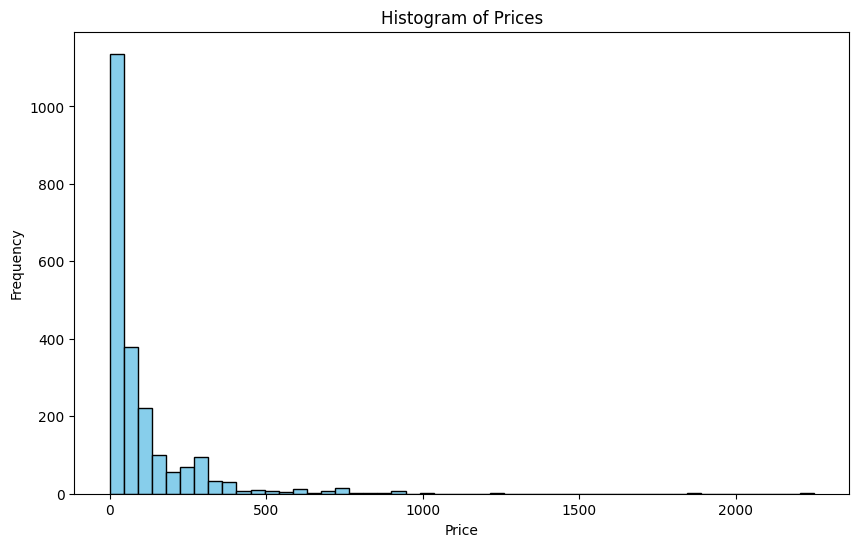

In [0]:
import matplotlib.pyplot as plt

prices_pd = item_df_parsed.select("price").toPandas()
plt.figure(figsize=(10, 6))
plt.hist(prices_pd["price"].dropna(), bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Histogram of Prices")
plt.show()

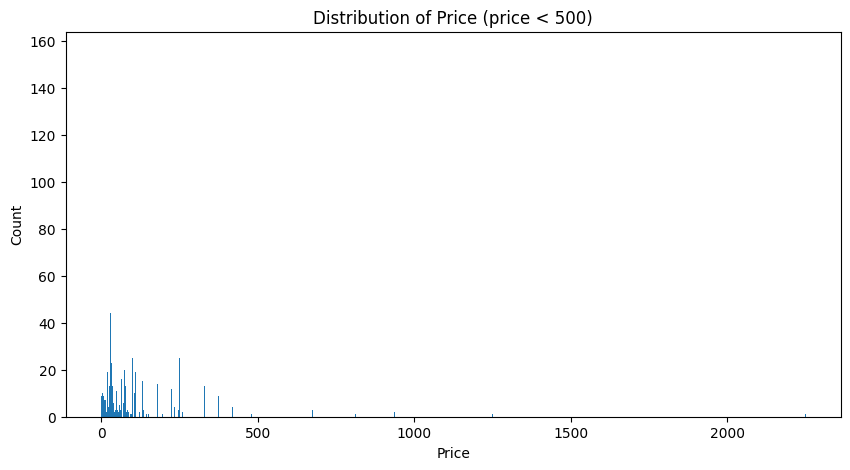

In [0]:
import matplotlib.pyplot as plt

# All values to see distribution
filtered_df = item_df_parsed  # .filter((item_df_parsed["price"] < 500) & (item_df_parsed["price"] != 0))

price_counts = filtered_df.groupBy("price").count().orderBy("price")

# Convert to Pandas for plotting
price_counts_pd = price_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(price_counts_pd["price"], price_counts_pd["count"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Price (price < 500)")
plt.show()

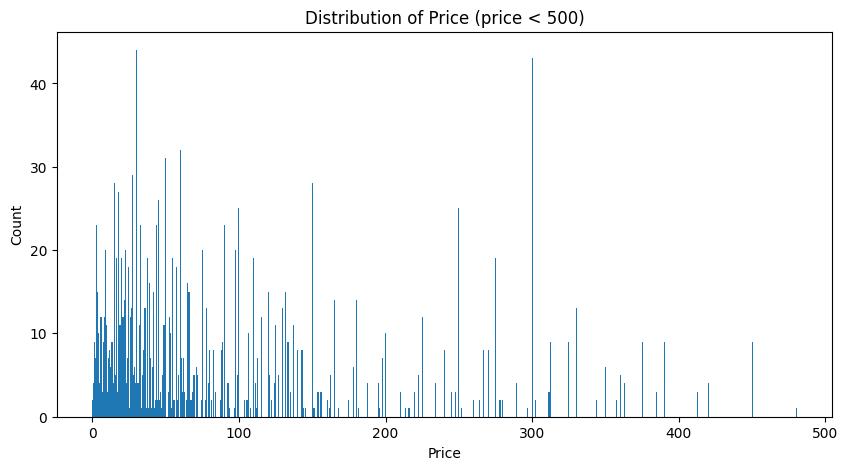

In [0]:
import matplotlib.pyplot as plt

# Filter for items with price < 500
# there are only how-to-manuals with price 0
filtered_df = item_df_parsed.filter(
    (item_df_parsed["price"] < 500) & (item_df_parsed["price"] != 0)
)

age_counts = filtered_df.groupBy("price").count().orderBy("price")

# Convert to Pandas for plotting
age_counts_pd = age_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(age_counts_pd["price"], age_counts_pd["count"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Price (price < 500)")
plt.show()

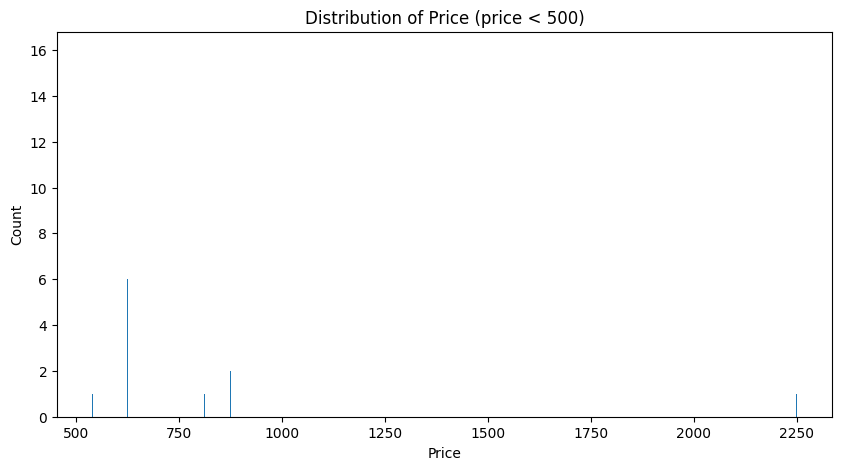

In [0]:
import matplotlib.pyplot as plt

# Filter for items with price < 500
# there are only how-to-manuals with price 0
filtered_df = item_df_parsed.filter((item_df_parsed["price"] > 500))

age_counts = filtered_df.groupBy("price").count().orderBy("price")

# Convert to Pandas for plotting
age_counts_pd = age_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(age_counts_pd["price"], age_counts_pd["count"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Price (price < 500)")
plt.show()

In [0]:
from pyspark.sql.functions import desc

display(item_df_parsed.groupBy("price").count().orderBy(desc("count")))

price,count
0.0,156
30.0,44
300.0,43
60.0,32
50.0,31
27.5,29
15.0,28
150.0,28
18.0,27
45.0,26


In [0]:
display(item_df_parsed.filter(item_df_parsed["price"] == 0))

adjective,category,created_at,id,modifier,name,price
null,instrument,2013-10-07T09:38:14.000Z,1178,how-to-manual,instrument how-to-manual,0.0
organic,tool,2013-09-09T11:36:06.000Z,107,how-to-manual,organic tool how-to-manual,0.0
reflective,mechanism,2014-01-21T07:14:49.000Z,1602,how-to-manual,reflective mechanism how-to-manual,0.0
matte,widget,2013-03-16T00:16:33.000Z,2389,how-to-manual,matte widget how-to-manual,0.0
rechargable,dongle,2013-03-16T00:54:44.000Z,1732,how-to-manual,rechargable dongle how-to-manual,0.0
matte,apparatus,2013-05-07T17:28:21.000Z,2309,how-to-manual,matte apparatus how-to-manual,0.0
extra-strength,instrument,2013-12-17T09:39:55.000Z,1756,how-to-manual,extra-strength instrument how-to-manual,0.0
reflective,gadget,2013-04-20T03:43:10.000Z,864,how-to-manual,reflective gadget how-to-manual,0.0
rechargable,gadget,2013-05-06T04:53:15.000Z,3842,how-to-manual,rechargable gadget how-to-manual,0.0
glossy,apparatus,2013-12-27T19:25:09.000Z,1545,how-to-manual,glossy apparatus how-to-manual,0.0


In [0]:
display(item_df_parsed.filter(col("price") > 1000.0))

adjective,category,created_at,id,modifier,name,price
extra-strength,contraption,2013-09-19T23:15:58.000Z,2592,storage_unit,extra-strength contraption storage_unit,1250.0
industrial-strength,apparatus,2013-03-30T01:18:30.000Z,2354,storage_unit,industrial-strength apparatus storage_unit,2250.0
industrial-strength,contraption,2014-01-14T15:42:03.000Z,669,storage_unit,industrial-strength contraption storage_unit,1875.0


There are only 3 items above 1000 and 59 above 500.

Check the quantiles of the prices

In [0]:
# Get quantiles for price distinctstribution
quantiles = item_df_parsed.approxQuantile(
    "price", [0.0, 0.25, 0.5, 0.75, 1.0], 0.01  # quartiles  # relative error tolerance
)

print("Quantiles:", quantiles)

Quantiles: [0.0, 13.75, 40.0, 111.25, 2250.0]


Use them as bucket splits?

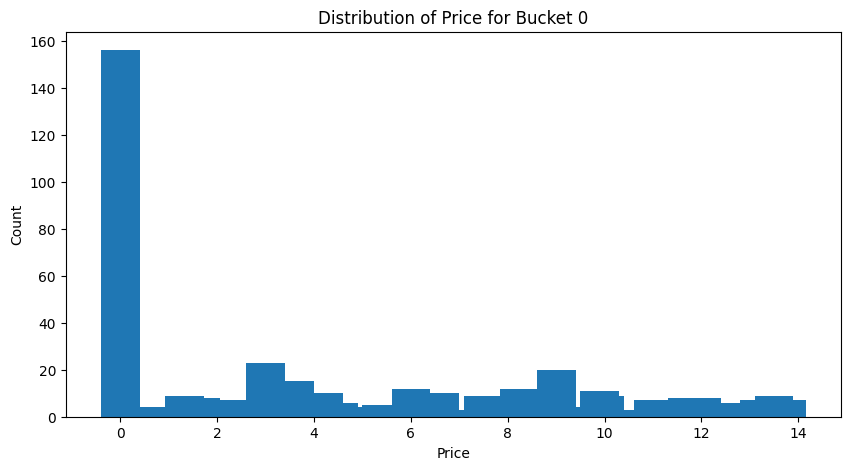

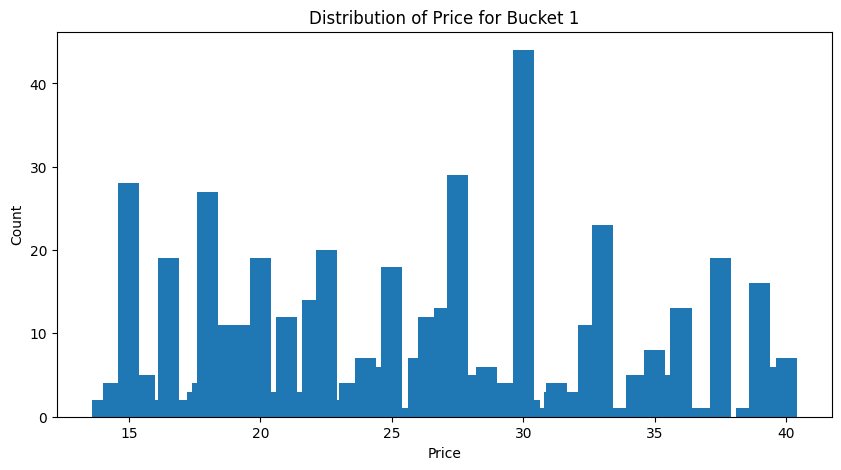

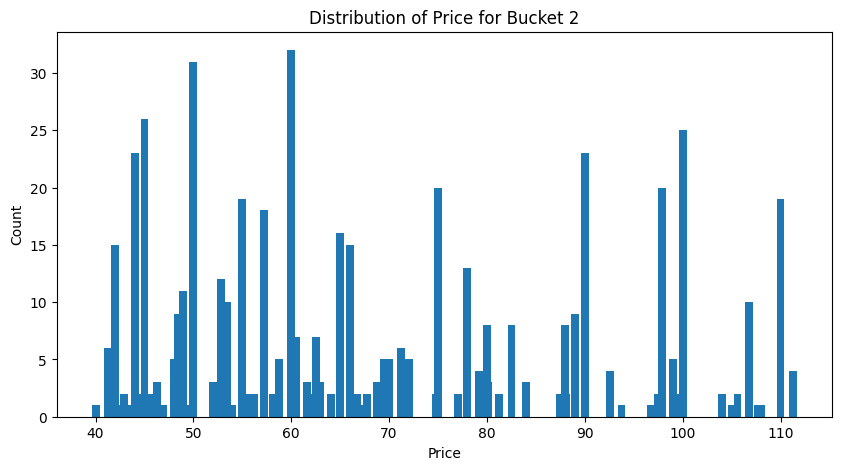

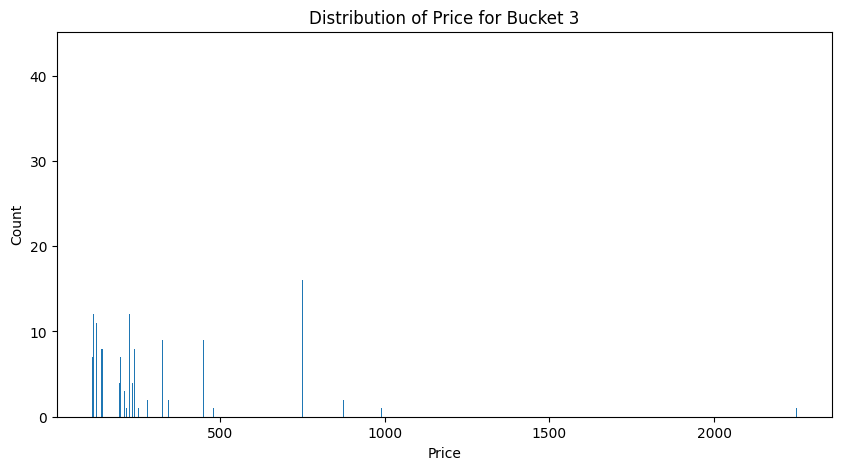

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Get unique bucket values using DataFrame API
buckets = [
    row["price_bucket"]
    for row in item_df_parsed.select("price_bucket")
    .distinct()
    .orderBy("price_bucket")
    .collect()
]

for bucket in buckets:
    bucket_df = item_df_parsed.filter(F.col("price_bucket") == bucket)
    price_counts = bucket_df.groupBy("price").count().orderBy("price")
    price_counts_pd = price_counts.toPandas()
    plt.figure(figsize=(10, 5))
    plt.bar(price_counts_pd["price"], price_counts_pd["count"])
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.title(f"Distribution of Price for Bucket {bucket}")
    plt.show()

In [0]:
import matplotlib.pyplot as plt

# Filter for items with price < 500
# there are only how-to-manuals with price 0
filtered_df = item_df_parsed.filter(
    (item_df_parsed["price"] < 500) & (item_df_parsed["price"] != 0)
)

age_counts = filtered_df.groupBy("price").count().orderBy("price")

# Convert to Pandas for plotting
age_counts_pd = age_counts.toPandas()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(age_counts_pd["price"], age_counts_pd["count"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Price (price < 500)")
plt.show()

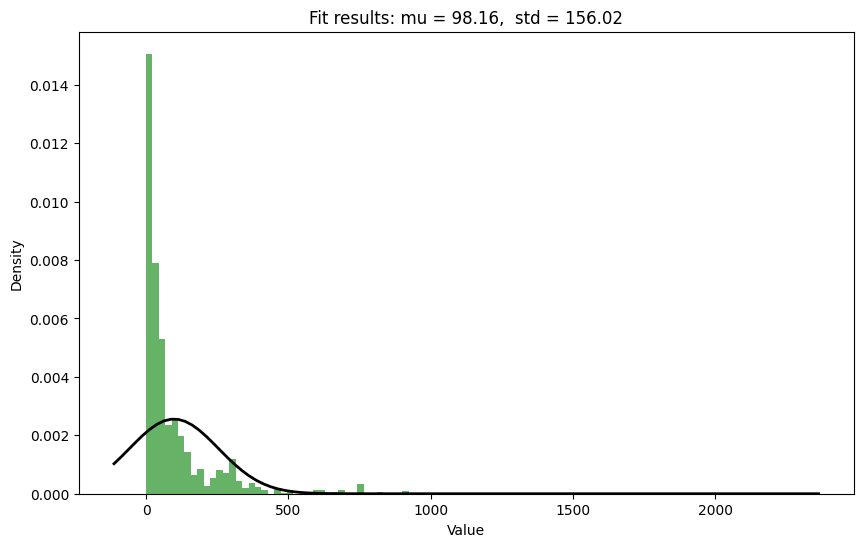

In [0]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

# Step 1: Collect your column from Spark
# Suppose your column is "value"
pdf = item_df_parsed.select("price").toPandas()

# Step 2: Extract values
data = pdf["price"].dropna().values

# Step 3: Plot histogram
plt.figure(figsize=(10, 6))
count, bins, _ = plt.hist(data, bins=100, density=True, alpha=0.6, color="g")

# Step 4: Fit Gaussian
mu, std = norm.fit(data)

# Step 5: Plot Gaussian curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, "k", linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [0]:
# Assign price buckets using when/otherwise instead of Bucketizer
from pyspark.sql.functions import when

# Use quantiles as splits
splits = quantiles
splits[0] = float("-inf")  # allow anything below min
splits[-1] = float("inf")  # allow anything above max


bucket_conditions = (
    when(F.col("price") <= splits[1], 0)
    .when((F.col("price") > splits[1]) & (F.col("price") <= splits[2]), 1)
    .when((F.col("price") > splits[2]) & (F.col("price") <= splits[3]), 2)
    .otherwise(3)
)
item_df_parsed = item_df_parsed.withColumn("price_bucket", bucket_conditions)
display(item_df_parsed.select("price", "price_bucket"))

price,price_bucket
150.0,3
35.2,1
300.0,3
16.5,1
16.5,1
195.0,3
0.0,0
41.25,2
15.0,1
37.5,1


## Useful partitions:
- Period of the year (vacations, Christmas, Black Friday) might be when the most expensive ones get sold -> don't do sales
- Time of the day (working hours, past midnight) might be when the cheapest ones get sold -> increase their price
- Price bucket
- platforms
- product adjective, modifier, category

#  Layer 3: Datamart

In [0]:
item_df_parsed = spark.read.format("delta").load(f"{bucket}/silver/item_clean")
event_df_parsed = spark.read.format("delta").load(f"{bucket}/silver/event_fact")

In [0]:
event_df_parsed.printSchema()
item_df_parsed.printSchema()

root
 |-- event_id: string (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- payload_event_name: string (nullable = true)
 |-- payload_platform: string (nullable = true)
 |-- payload_parameter_name: string (nullable = true)
 |-- payload_parameter_value: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)

root
 |-- adjective: string (nullable = true)
 |-- category: string (nullable = true)
 |-- created_at: timestamp (nullable = true)
 |-- id: integer (nullable = true)
 |-- modifier: string (nullable = true)
 |-- name: string (nullable = true)
 |-- price: float (nullable = true)
 |-- price_bucket: string (nullable = true)



In [0]:
display(event_df_parsed.head(3))

event_id,event_time,user_id,payload_event_name,payload_platform,payload_parameter_name,payload_parameter_value,year,month
50e6a6d00111460e9f6acdbd94f500a4,2014-09-06T13:10:31.000Z,29614,view_user_profile,iOS,viewed_user_id,1393,2014,9
f53ec02b56294112aff8acbaecd52037,2014-09-06T14:13:59.000Z,32808,view_user_profile,web,viewed_user_id,37415,2014,9
45c935c652774f1bb92141a546b392d4,2014-09-22T16:23:32.000Z,11059,view_user_profile,web,viewed_user_id,31459,2014,9


In [0]:
display(item_df_parsed.head(3))

adjective,category,created_at,id,modifier,name,price,price_bucket
organic,tool,2013-06-24T15:10:15.000Z,1606,warmer,organic tool warmer,41.25,medium-high
industrial-strength,tool,2013-04-15T04:41:01.000Z,1273,cleaner,industrial-strength tool cleaner,45.0,medium-high
industrial-strength,tool,2013-12-07T22:22:05.000Z,207,null,industrial-strength tool,75.0,medium-high


### Total number of item views in a particular year.

In [0]:
from pyspark.sql import functions as F, Window


views_df = (
    event_df_parsed.filter(
        (F.col("payload_event_name") == "view_item")
        & (F.col("payload_parameter_name") == "item_id")
    )  # filter further for the response with the item id
    .withColumnRenamed("payload_platform", "platform")
    .withColumnRenamed("payload_event_name", "event_name")
)

# Join with item dimension
views_with_items = views_df.join(
    item_df_parsed, views_df["payload_parameter_value"] == item_df_parsed["id"], "inner"
)

# Aggregate: total views + most used platform
agg_df = (
    views_with_items.groupBy("id", "name", "year")
    .agg(
        F.count("*").alias("total_views"),
        F.expr("mode() within group (order by platform)").alias(
            "most_used_platform"
        ),  # for Spark SQL 3.x
    )
    .orderBy("id", "total_views")
)

# Add ranking by total views per year
window_rank = Window.partitionBy("year").orderBy(F.desc("total_views"))
top_item_df = agg_df.withColumn("rank", F.dense_rank().over(window_rank))

In [0]:
display(top_item_df)

id,name,year,total_views,most_used_platform,rank
3517,prize-winning widget wrapper,2013,12,web,1
2086,organic device,2013,12,web,1
3063,fuzzy gadget wrapper,2013,11,web,2
3200,prize-winning widget refill,2013,10,web,3
3309,industrial-strength dongle,2013,10,mobile web,3
3538,organic dongle,2013,10,web,3
3978,fuzzy dongle,2013,10,android,3
3264,organic dongle wrapper,2013,9,iOS,4
80,rechargable module cleaner,2013,9,mobile web,4
138,matte widget refill,2013,9,web,4


In [0]:
# Save to Gold layer
top_item_df.write.mode("overwrite").format("delta").save(
    f"{bucket}/gold_layer/top_item"
)